# EWS Fraud Detection - Tahap 8: Pelatihan Model XGBoost

Notebook ini bertujuan untuk melakukan pelatihan model **XGBoost Classifier** menggunakan dua target weak label yang telah didefinisikan sebelumnya:
- **Model A (weak_label_t3)**: Target berdasarkan threshold >= 3 aturan terpicu.
- **Model B (weak_label_t2)**: Target berdasarkan threshold >= 2 aturan terpicu.

Untuk mencegah kebocoran informasi (*data leakage*) akibat data panel emiten, kita menggunakan pembagian data berbasis kelompok emiten menggunakan **GroupShuffleSplit**.

Kita akan membandingkan dua skenario pembagian data untuk masing-masing model:
1. **Skenario 80/10/10**: 80% Train, 10% Validation, 10% Test.
2. **Skenario 70/15/15**: 70% Train, 15% Validation, 15% Test.

Pada model A yang datanya sangat imbalance, kita akan menghitung dan menerapkan bobot kelas (`scale_pos_weight`) untuk mengoptimalkan performa pendeteksian.

In [1]:
import pandas as pd
import numpy as np
import os
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set gaya visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Memuat Dataset & Penanganan Missing Value

In [2]:
dataset_path = "Final_EWS_Dataset.xlsx"

if os.path.exists(dataset_path):
    df = pd.read_excel(dataset_path)
    print(f"Dataset EWS berhasil dimuat. Dimensi: {df.shape}")
else:
    print("[ERROR] Berkas Final_EWS_Dataset.xlsx tidak ditemukan!")

Dataset EWS berhasil dimuat. Dimensi: (1637, 84)


In [3]:
# Definisikan fitur latih yang dispesifikasikan (menghindari leakage data)
features = [
    # Beneish
    "dsri", "gmi", "aqi", "sgi", "lvgi", "tata", "sgai",
    # Trend
    "revenue_growth", "asset_growth", "net_income_growth_assets",
    # Quality
    "cfo_to_net_income",
    # Narrative
    "sentiment", "risk_words", "readability", "text_length",
    # Anomaly
    "anomaly_score_05"
]

targets = ['weak_label_t3', 'weak_label_t2']

# Cek jumlah missing values (NaN) pada fitur latih
print("=== Jumlah Missing Value per Fitur ===")
print(df[features].isna().sum())

# Hapus baris yang mengandung NaN pada fitur latih atau target
df_clean = df.dropna(subset=features + targets).copy()
print(f"\nDimensi dataset setelah menghapus NaN: {df_clean.shape} (Terhapus: {len(df) - len(df_clean)} baris)")

=== Jumlah Missing Value per Fitur ===
dsri                        0
gmi                         0
aqi                         0
sgi                         0
lvgi                        0
tata                        0
sgai                        0
revenue_growth              0
asset_growth                0
net_income_growth_assets    0
cfo_to_net_income           1
sentiment                   0
risk_words                  0
readability                 0
text_length                 0
anomaly_score_05            0
dtype: int64

Dimensi dataset setelah menghapus NaN: (1636, 84) (Terhapus: 1 baris)


## 2. Fungsi Pembagi Data Berkelompok (Group Splitter)
Kita membuat fungsi pembagi data berbasis `GroupShuffleSplit` untuk membagi kelompok emiten (`kode`) ke dalam Train, Validation, dan Test secara bersih tanpa kebocoran data antar tahun.

In [4]:
def split_data_groupwise(df, X_cols, y_col, test_size_pct, val_size_pct, random_state=42):
    """
    Membagi dataset menjadi Train, Validation, dan Test secara kelompok (Group-wise)
    menggunakan GroupShuffleSplit.
    """
    temp_size = test_size_pct + val_size_pct
    gss1 = GroupShuffleSplit(n_splits=1, test_size=temp_size, random_state=random_state)
    
    X = df[X_cols]
    y = df[y_col]
    groups = df["kode"]
    
    # Split pertama: Memisahkan Train dari Temp (Val + Test)
    train_idx, temp_idx = next(gss1.split(X, y, groups=groups))
    
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    groups_train = groups.iloc[train_idx]
    
    X_temp, y_temp = X.iloc[temp_idx], y.iloc[temp_idx]
    groups_temp = groups.iloc[temp_idx]
    
    # Split kedua: Memisahkan Validation dan Test (berdasarkan rasio relatif)
    val_relative_ratio = val_size_pct / temp_size
    gss2 = GroupShuffleSplit(n_splits=1, test_size=1.0 - val_relative_ratio, random_state=random_state)
    
    val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups=groups_temp))
    
    X_val, y_val = X_temp.iloc[val_idx], y_temp.iloc[val_idx]
    X_test, y_test = X_temp.iloc[test_idx], y_temp.iloc[test_idx]
    
    return X_train, y_train, X_val, y_val, X_test, y_test

## 3. Model A: Target weak_label_t3 (Threshold >= 3)

### A. Skenario 80/10/10 (Train/Val/Test)

Train size: 1311 | Val size: 164 | Test size: 161
Distribusi kelas di Train:
weak_label_t3
0    1244
1      67
Name: count, dtype: int64
Scale Pos Weight: 18.57

=== HASIL EVALUASI VALIDATION (80/10/10) ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       161
           1       0.60      1.00      0.75         3

    accuracy                           0.99       164
   macro avg       0.80      0.99      0.87       164
weighted avg       0.99      0.99      0.99       164

Confusion Matrix:
[[159   2]
 [  0   3]]

=== HASIL EVALUASI TEST (80/10/10) ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       153
           1       1.00      0.75      0.86         8

    accuracy                           0.99       161
   macro avg       0.99      0.88      0.93       161
weighted avg       0.99      0.99      0.99       161

Confusion Matrix:
[[153   0]
 [  2   6]]


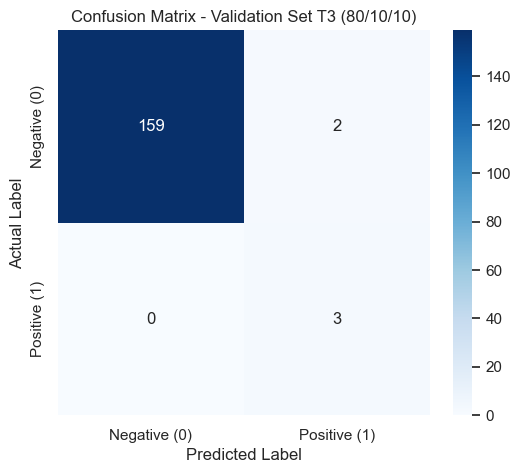

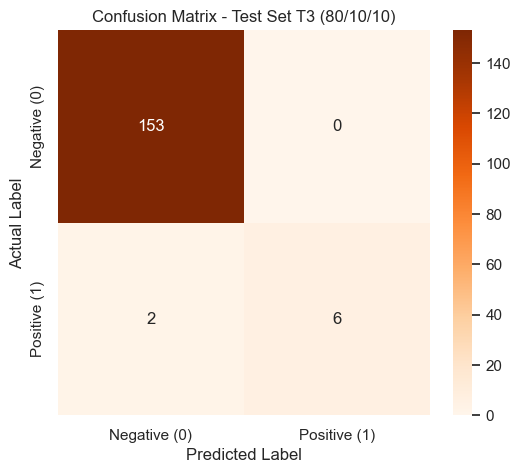

In [5]:
# Split data
X_train, y_train, X_val, y_val, X_test, y_test = split_data_groupwise(
    df_clean, features, 'weak_label_t3', test_size_pct=0.10, val_size_pct=0.10
)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")
print(f"Distribusi kelas di Train:\n{y_train.value_counts()}")

# Hitung imbalance bobot positif
neg_count = sum(y_train == 0)
pos_count = sum(y_train == 1)
scale_pos_weight = neg_count / max(1, pos_count)
print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

# Latih model
model_a_80 = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
model_a_80.fit(X_train, y_train)

# Evaluasi Validation
y_pred_val = model_a_80.predict(X_val)
print("\n=== HASIL EVALUASI VALIDATION (80/10/10) ===")
print(classification_report(y_val, y_pred_val))
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_val))

# Evaluasi Test
y_pred_test = model_a_80.predict(X_test)
print("\n=== HASIL EVALUASI TEST (80/10/10) ===")
print(classification_report(y_test, y_pred_test))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

cm_val = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative (0)', 'Positive (1)'], 
            yticklabels=['Negative (0)', 'Positive (1)'])

plt.title('Confusion Matrix - Validation Set T3 (80/10/10)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

cm_test = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Negative (0)', 'Positive (1)'], 
            yticklabels=['Negative (0)', 'Positive (1)'])

plt.title('Confusion Matrix - Test Set T3 (80/10/10)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### B. Skenario 70/15/15 (Train/Val/Test)

Train size: 1150 | Val size: 244 | Test size: 242
Distribusi kelas di Train:
weak_label_t3
0    1093
1      57
Name: count, dtype: int64
Scale Pos Weight: 19.18

=== HASIL EVALUASI VALIDATION (70/15/15) ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       235
           1       0.64      0.78      0.70         9

    accuracy                           0.98       244
   macro avg       0.81      0.88      0.84       244
weighted avg       0.98      0.98      0.98       244

Confusion Matrix:
[[231   4]
 [  2   7]]

=== HASIL EVALUASI TEST (70/15/15) ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       230
           1       0.77      0.83      0.80        12

    accuracy                           0.98       242
   macro avg       0.88      0.91      0.89       242
weighted avg       0.98      0.98      0.98       242

Confusion Matrix:
[[227   3]
 [  2  10]]


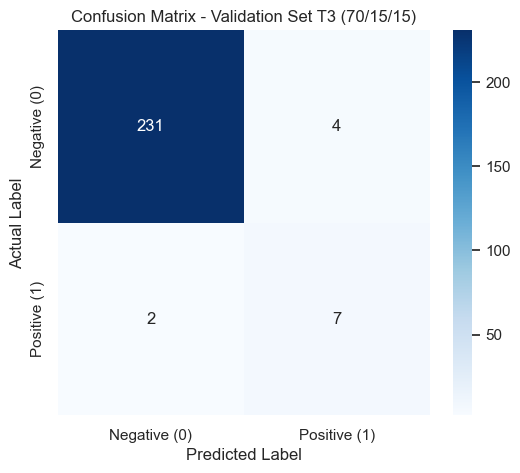

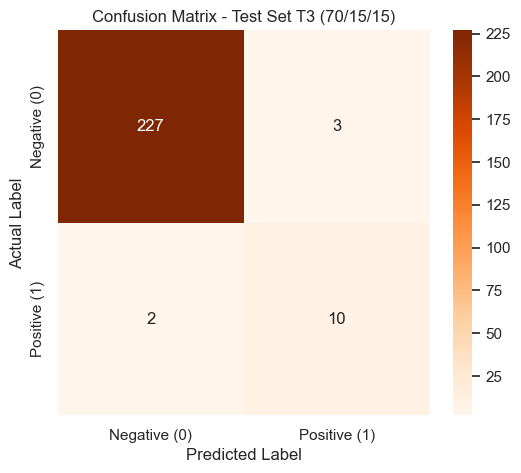

In [6]:
# Split data
X_train, y_train, X_val, y_val, X_test, y_test = split_data_groupwise(
    df_clean, features, 'weak_label_t3', test_size_pct=0.15, val_size_pct=0.15
)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")
print(f"Distribusi kelas di Train:\n{y_train.value_counts()}")

# Hitung imbalance bobot positif
neg_count = sum(y_train == 0)
pos_count = sum(y_train == 1)
scale_pos_weight = neg_count / max(1, pos_count)
print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

# Latih model
model_a_70 = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
model_a_70.fit(X_train, y_train)

# Evaluasi Validation
y_pred_val = model_a_70.predict(X_val)
print("\n=== HASIL EVALUASI VALIDATION (70/15/15) ===")
print(classification_report(y_val, y_pred_val))
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_val))

# Evaluasi Test
y_pred_test = model_a_70.predict(X_test)
print("\n=== HASIL EVALUASI TEST (70/15/15) ===")
print(classification_report(y_test, y_pred_test))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

cm_val = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative (0)', 'Positive (1)'], 
            yticklabels=['Negative (0)', 'Positive (1)'])

plt.title('Confusion Matrix - Validation Set T3 (70/15/15)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

cm_test = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Negative (0)', 'Positive (1)'], 
            yticklabels=['Negative (0)', 'Positive (1)'])

plt.title('Confusion Matrix - Test Set T3 (70/15/15)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## 4. Model B: Target weak_label_t2 (Threshold >= 2)

### A. Skenario 80/10/10 (Train/Val/Test)

Train size: 1311 | Val size: 164 | Test size: 161
Distribusi kelas di Train:
weak_label_t2
0    965
1    346
Name: count, dtype: int64
Scale Pos Weight: 2.79

=== HASIL EVALUASI VALIDATION (80/10/10) ===
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       124
           1       0.90      0.90      0.90        40

    accuracy                           0.95       164
   macro avg       0.93      0.93      0.93       164
weighted avg       0.95      0.95      0.95       164

Confusion Matrix:
[[120   4]
 [  4  36]]

=== HASIL EVALUASI TEST (80/10/10) ===
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       126
           1       0.78      0.91      0.84        35

    accuracy                           0.93       161
   macro avg       0.88      0.92      0.90       161
weighted avg       0.93      0.93      0.93       161

Confusion Matrix:
[[117   9]
 [  3  32]]


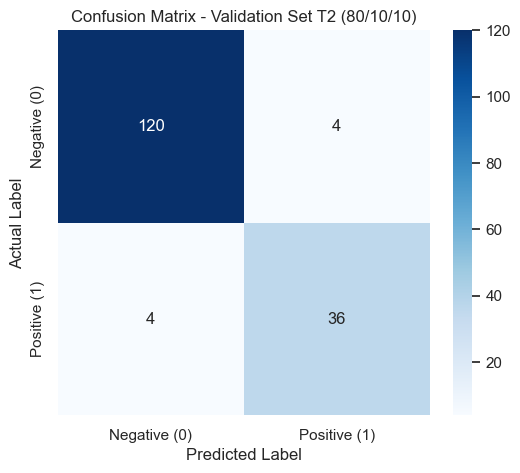

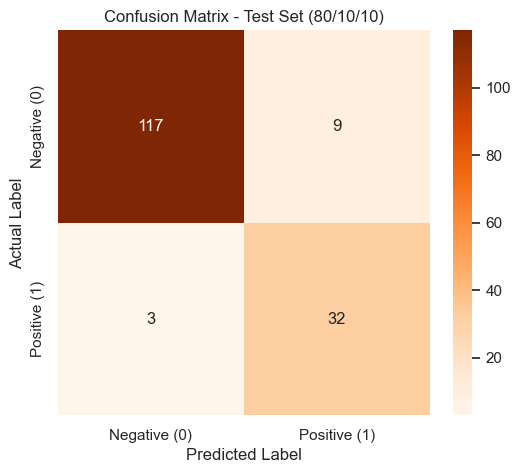

In [7]:
# Split data
X_train, y_train, X_val, y_val, X_test, y_test = split_data_groupwise(
    df_clean, features, 'weak_label_t2', test_size_pct=0.10, val_size_pct=0.10
)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")
print(f"Distribusi kelas di Train:\n{y_train.value_counts()}")

# Model B (t2) lebih seimbang, namun kita bisa periksa jika bobot kelas diperlukan
neg_count = sum(y_train == 0)
pos_count = sum(y_train == 1)
scale_pos_weight = neg_count / max(1, pos_count)
print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

# Latih model
model_b_80 = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
model_b_80.fit(X_train, y_train)

# Evaluasi Validation
y_pred_val = model_b_80.predict(X_val)
print("\n=== HASIL EVALUASI VALIDATION (80/10/10) ===")
print(classification_report(y_val, y_pred_val))
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_val))

# Evaluasi Test
y_pred_test = model_b_80.predict(X_test)
print("\n=== HASIL EVALUASI TEST (80/10/10) ===")
print(classification_report(y_test, y_pred_test))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

cm_val = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative (0)', 'Positive (1)'], 
            yticklabels=['Negative (0)', 'Positive (1)'])

plt.title('Confusion Matrix - Validation Set T2 (80/10/10)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

cm_test = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Negative (0)', 'Positive (1)'], 
            yticklabels=['Negative (0)', 'Positive (1)'])

plt.title('Confusion Matrix - Test Set (80/10/10)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### B. Skenario 70/15/15 (Train/Val/Test)

Train size: 1150 | Val size: 244 | Test size: 242
Distribusi kelas di Train:
weak_label_t2
0    855
1    295
Name: count, dtype: int64
Scale Pos Weight: 2.90

=== HASIL EVALUASI VALIDATION (70/15/15) ===
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       175
           1       0.87      0.84      0.85        69

    accuracy                           0.92       244
   macro avg       0.90      0.89      0.90       244
weighted avg       0.92      0.92      0.92       244

Confusion Matrix:
[[166   9]
 [ 11  58]]

=== HASIL EVALUASI TEST (70/15/15) ===
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       185
           1       0.89      0.95      0.92        57

    accuracy                           0.96       242
   macro avg       0.93      0.95      0.94       242
weighted avg       0.96      0.96      0.96       242

Confusion Matrix:
[[178   7]
 [  3  54]]


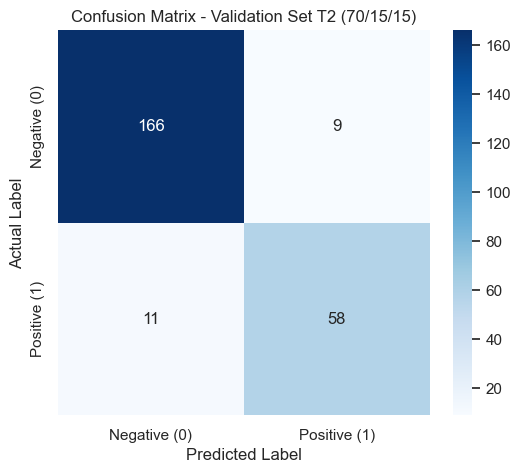

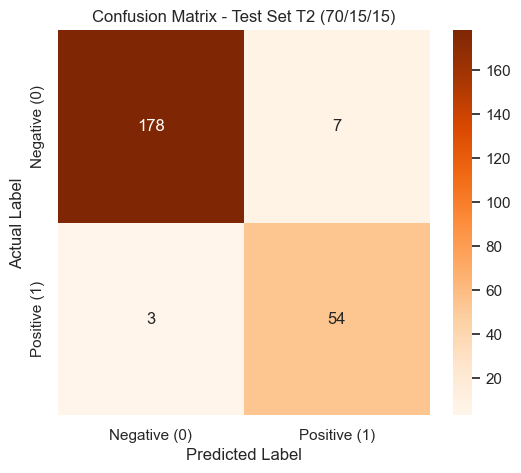

In [8]:
# Split data
X_train, y_train, X_val, y_val, X_test, y_test = split_data_groupwise(
    df_clean, features, 'weak_label_t2', test_size_pct=0.15, val_size_pct=0.15
)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")
print(f"Distribusi kelas di Train:\n{y_train.value_counts()}")

neg_count = sum(y_train == 0)
pos_count = sum(y_train == 1)
scale_pos_weight = neg_count / max(1, pos_count)
print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

# Latih model
model_b_70 = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
model_b_70.fit(X_train, y_train)

# Evaluasi Validation
y_pred_val = model_b_70.predict(X_val)
print("\n=== HASIL EVALUASI VALIDATION (70/15/15) ===")
print(classification_report(y_val, y_pred_val))
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_val))

# Evaluasi Test
y_pred_test = model_b_70.predict(X_test)
print("\n=== HASIL EVALUASI TEST (70/15/15) ===")
print(classification_report(y_test, y_pred_test))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

cm_val = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative (0)', 'Positive (1)'], 
            yticklabels=['Negative (0)', 'Positive (1)'])

plt.title('Confusion Matrix - Validation Set T2 (70/15/15)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

cm_test = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Negative (0)', 'Positive (1)'], 
            yticklabels=['Negative (0)', 'Positive (1)'])

plt.title('Confusion Matrix - Test Set T2 (70/15/15)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## 5. Perbandingan Feature Importance Model A vs Model B

=== Perbandingan Feature Importance ===


,Feature,Model A (T3) Importance,Model B (T2) Importance
15,anomaly_score_05,0.308738,0.108183
12,risk_words,0.172333,0.056944
3,sgi,0.148532,0.154076
5,tata,0.087434,0.189024
11,sentiment,0.053890,0.040925
14,text_length,0.044062,0.030194
10,cfo_to_net_income,0.041392,0.181863
8,asset_growth,0.037867,0.009250
13,readability,0.022627,0.023423
0,dsri,0.021408,0.046694


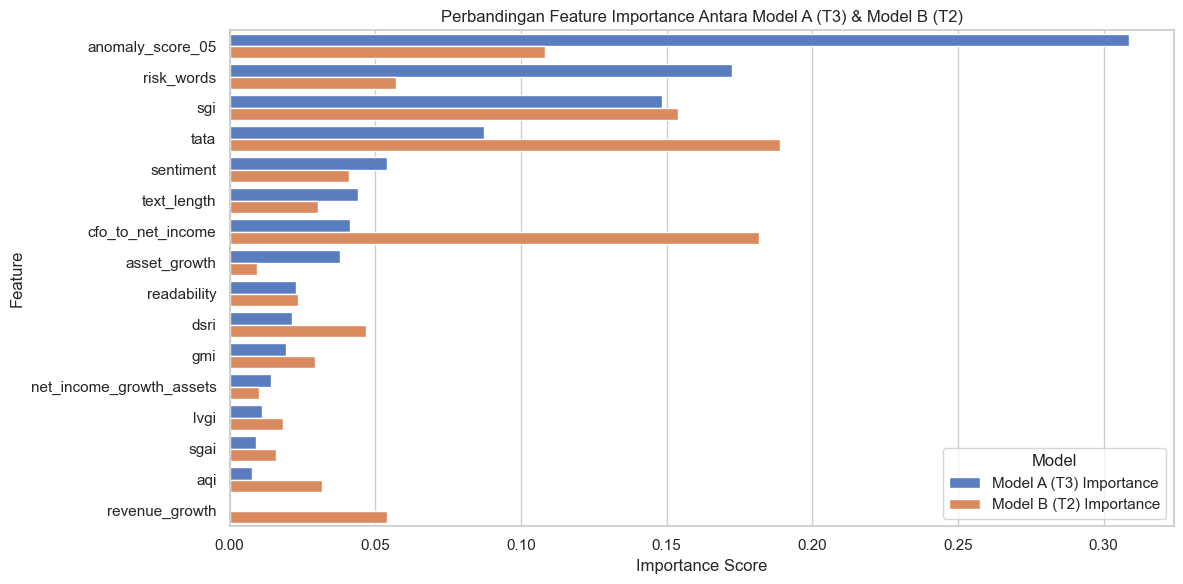

In [11]:
# Membuat dataframe perbandingan feature importance (menggunakan skenario 80/10/10)
df_imp = pd.DataFrame({
    'Feature': features,
    'Model A (T3) Importance': model_a_80.feature_importances_,
    'Model B (T2) Importance': model_b_80.feature_importances_
}).sort_values(by='Model A (T3) Importance', ascending=False)

print("=== Perbandingan Feature Importance ===")
display(df_imp)

# Visualisasi perbandingan
df_melt = pd.melt(df_imp, id_vars=['Feature'], value_vars=['Model A (T3) Importance', 'Model B (T2) Importance'],
                  var_name='Model', value_name='Importance')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melt, x='Importance', y='Feature', hue='Model', palette='muted')
plt.title('Perbandingan Feature Importance Antara Model A (T3) & Model B (T2)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 6. Impor ke JobLib dan Pickle

In [10]:
import joblib
import pickle

joblib_filename = 'model_xgb_b80.joblib'
joblib.dump(model_b_80, joblib_filename)
print(f"Model berhasil diekspor ke {joblib_filename} menggunakan Joblib.")

pickle_filename = 'model_xgb_b80.pkl'
with open(pickle_filename, 'wb') as file:
    pickle.dump(model_b_80, file)
print(f"Model berhasil diekspor ke {pickle_filename} menggunakan Pickle.")

Model berhasil diekspor ke model_xgb_b80.joblib menggunakan Joblib.
Model berhasil diekspor ke model_xgb_b80.pkl menggunakan Pickle.
